In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import plotly.express as ps

In [5]:
df=pd.read_csv("Teen_Mental_Health_Dataset.csv")
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [6]:
df=df.dropna()
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [8]:
x=df.drop("depression_label",axis=1)
x=pd.get_dummies(x)
y=df["depression_label"]
d={"model":[],"acc":[],"test":[]}
test=[0.05,0.10,0.15,0.20,0.25]
for i in test:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=42)
    d["model"].append("knn")
    d["test"].append(i)
    knn=KNeighborsClassifier(n_neighbors=29)
    knn.fit(x_train,y_train)
    d["acc"].append(accuracy_score(y_test,knn.predict(x_test)))
    d["model"].append("dt")
    d["test"].append(i)
    dt=DecisionTreeClassifier(criterion="entropy",random_state=42,max_depth=4)
    dt.fit(x_train,y_train)
    d["acc"].append(accuracy_score(y_test,dt.predict(x_test)))
    d["model"].append("rf")
    d["test"].append(i)
    rf=RandomForestClassifier(criterion="entropy",n_estimators=100,random_state=42,max_depth=4)
    rf.fit(x_train,y_train)
    d["acc"].append(accuracy_score(y_test,rf.predict(x_test)))
    d["model"].append("svm")
    d["test"].append(i)
    svm=SVC(C=10,kernel="rbf",random_state=42)
    svm.fit(x_train,y_train)
    d["acc"].append(accuracy_score(y_test,svm.predict(x_test)))
df=pd.DataFrame(d)
print(df)   

   model       acc  test
0    knn  0.933333  0.05
1     dt  1.000000  0.05
2     rf  0.933333  0.05
3    svm  0.950000  0.05
4    knn  0.958333  0.10
5     dt  1.000000  0.10
6     rf  0.958333  0.10
7    svm  0.975000  0.10
8    knn  0.972222  0.15
9     dt  1.000000  0.15
10    rf  0.972222  0.15
11   svm  0.983333  0.15
12   knn  0.975000  0.20
13    dt  1.000000  0.20
14    rf  0.975000  0.20
15   svm  0.983333  0.20
16   knn  0.973333  0.25
17    dt  0.996667  0.25
18    rf  0.973333  0.25
19   svm  0.983333  0.25


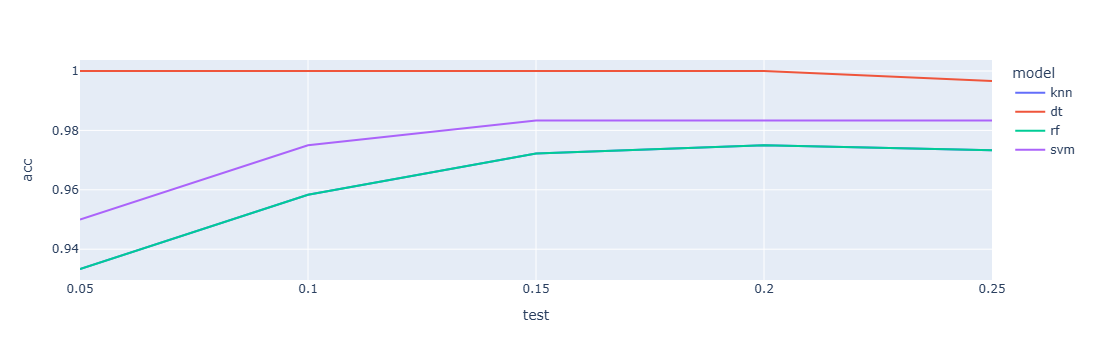

In [12]:
ps.line(data_frame=d,x="test",y="acc",color="model")

In [15]:
result=df.groupby("model")["acc"].max().reset_index()
print(result)

  model       acc
0    dt  1.000000
1   knn  0.975000
2    rf  0.975000
3   svm  0.983333


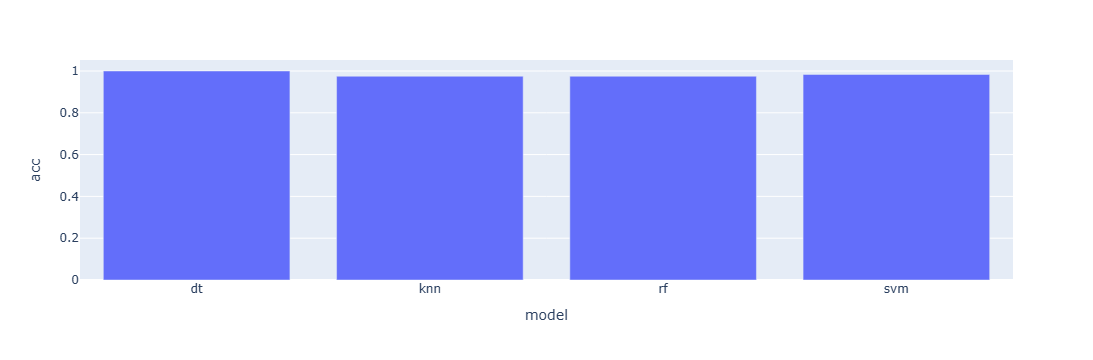

In [18]:
ps.bar(data_frame=result,x="model",y="acc")

In [21]:
df1=pd.read_csv("created_house_price_prediction.csv")
df1

,Area,Bedrooms,Bathrooms,Garage,YearBuilt,Location,Price
0,8000.0,3.0,2.0,1.0,2004.0,Lagos,105402678.0
1,8100.0,2.0,2.0,1.0,2013.0,Kaduna,62530695.0
2,8200.0,2.0,1.0,0.0,2023.0,Kano,71488309.0
3,8300.0,3.0,1.0,0.0,2006.0,Kano,70608894.0
4,8400.0,3.0,2.0,1.0,2003.0,Lagos,107029977.0
...,...,...,...,...,...,...,...
2045,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2046,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2047,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2048,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df1=df1.dropna()

In [23]:
df1

,Area,Bedrooms,Bathrooms,Garage,YearBuilt,Location,Price
0,8000.0,3.0,2.0,1.0,2004.0,Lagos,105402678.0
1,8100.0,2.0,2.0,1.0,2013.0,Kaduna,62530695.0
2,8200.0,2.0,1.0,0.0,2023.0,Kano,71488309.0
3,8300.0,3.0,1.0,0.0,2006.0,Kano,70608894.0
4,8400.0,3.0,2.0,1.0,2003.0,Lagos,107029977.0
...,...,...,...,...,...,...,...
1994,207400.0,3.0,2.0,0.0,2014.0,Jigawa,200000000.0
1995,207500.0,3.0,2.0,1.0,2011.0,Lagos,200000000.0
1996,207600.0,1.0,2.0,1.0,2004.0,Jigawa,200000000.0
1997,207700.0,1.0,1.0,1.0,2001.0,Lagos,200000000.0


In [40]:
x=df1.drop(["Price"],axis=1)
x=pd.get_dummies(x)
y=df1["Price"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
r2_poly=0
deg=0
for i in range(1,6):
    poly=PolynomialFeatures(degree=i)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    model=LinearRegression()
    model.fit(x_train_poly,y_train)
    y_pred=model.predict(x_test_poly)
    r2=r2_score(y_test,y_pred)
    if r2_poly<r2:
        deg=i
        r2_poly=r2
    print("MSE: ",mean_squared_error(y_test,y_pred))
    print("R2_SCORE: ",r2)
print("degree",deg,">",r2_poly)

MSE:  401114139847949.25
R2_SCORE:  0.21425046975387385
MSE:  257161051953968.8
R2_SCORE:  0.4962427007758259
MSE:  125774521932174.31
R2_SCORE:  0.7536180809716666
MSE:  47215458395561.36
R2_SCORE:  0.9075088096651711
MSE:  39362651139290.88
R2_SCORE:  0.922891811658237
degree 5 > 0.922891811658237


poly MSE:  49788989562592.14
poly R2_SCORE:  0.9356090536947514
MSE:  565504405722740.8
R2_SCORE:  0.26864625805475495
-----------------------------------
poly MSE:  40030186667506.06
poly R2_SCORE:  0.9188048061631952
MSE:  404787640491471.44
R2_SCORE:  0.1789493462660503
-----------------------------------
poly MSE:  42474875502643.23
poly R2_SCORE:  0.9242589492992966
MSE:  431647180772616.25
R2_SCORE:  0.23028824412493276
-----------------------------------
poly MSE:  39362651139290.88
poly R2_SCORE:  0.922891811658237
MSE:  401114139847963.4
R2_SCORE:  0.21425046975384632
-----------------------------------
poly MSE:  38550581893289.13
poly R2_SCORE:  0.92073502223097
MSE:  399457165860851.8
R2_SCORE:  0.17866445027248656
-----------------------------------


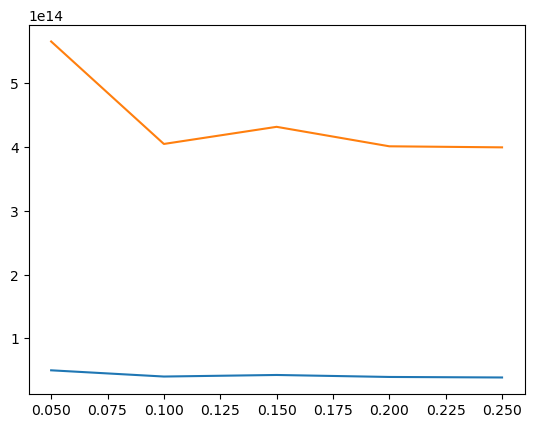

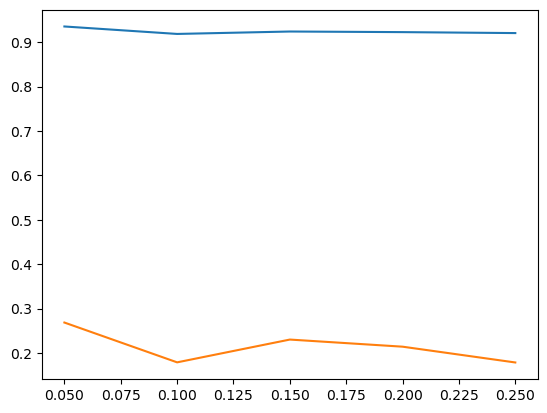

In [46]:
poly_mse=[]
poly_r2=[]
mse=[]
r2=[]
test=[0.05,0.10,0.15,0.20,0.25]
for i in test:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=42)
    poly=PolynomialFeatures(degree=5)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    model=LinearRegression()
    model.fit(x_train_poly,y_train)
    y_pred=model.predict(x_test_poly)
    poly_r2.append(r2_score(y_test,y_pred))
    poly_mse.append(mean_squared_error(y_test,y_pred))
    print("poly MSE: ",mean_squared_error(y_test,y_pred))
    print("poly R2_SCORE: ",r2_score(y_test,y_pred))

    lr=LinearRegression()
    lr.fit(x_train,y_train)
    y_pred=lr.predict(x_test)
    r2.append(r2_score(y_test,y_pred))
    mse.append(mean_squared_error(y_test,y_pred))
    print("MSE: ",mean_squared_error(y_test,y_pred))
    print("R2_SCORE: ",r2_score(y_test,y_pred))
    print("-----------------------------------")

plt.plot(test,poly_mse)
plt.plot(test,mse)
plt.show()
plt.plot(test,poly_r2)
plt.plot(test,r2)
plt.show()